# Mérési notebook
---
# **4. mérési fázis**. Saját modellek fejlesztése.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 1. lépés: saját modellek megismerése és üres tesztelése.

---

Saját modell tesztelése. ResNet18 modern fejrésszel.

(3 különböző fejrész tesztelése a cél)

✅ 0. Telepítés és beállítások
✅ 1. Drive csatolás + ZIP kicsomagolás

In [ ]:
# 🧰 Alapcsomagok
!pip install -q timm scikit-learn scikit-plot

# 🖼️ matplotlib + seaborn (ha valami hiányzik)
!pip install -q matplotlib seaborn

# 📁 Google Drive csatolása
from google.colab import drive
drive.mount('/content/drive')

# 📦 Kitömörítés, ha szükséges
import zipfile, os

diploma_path = "/content/drive/MyDrive/diplomamunka"
dataset_zip = os.path.join(diploma_path, "imagenet_splitted_db.zip")
dataset_dir = "/content/imagenet_splitted_db"

if not os.path.exists(dataset_dir):
    with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
        zip_ref.extractall("/content")
    print("✅ Kicsomagolva:", dataset_dir)
else:
    print("✅ Már ki van csomagolva:", dataset_dir)

# ⚙️ GPU ellenőrzés
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📡 Aktív eszköz: {device}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.3 MB/s eta 0:00:00
Mounted at /content/drive
✅ Kicsomagolva: /content/imagenet_splitted_db
📡 Aktív eszköz: cuda


Mappa pontosítás

In [ ]:
extract_path = "/content/imagenet_splitted_db/imagenet_splitted_db"

🧠 2. ResNet18 modell betöltése

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
from copy import deepcopy

# Eszköz beállítása
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Előre betanított ResNet18 letöltése ImageNet1k súlyokkal
resnet18_base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Általános paraméterek
num_classes = 114
in_features = resnet18_base.fc.in_features  # 512 a ResNet18 esetén


🧪 3. Három különböző osztályozó fej definiálása

In [ ]:
# Baseline fej: gyors, stabil tanulás
baseline_head = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

# Deep fej: mélyebb FC architektúra
deep_head = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)

# Hybrid fej: külön osztályban definiáljuk
class ResNet18HybridHead(nn.Module):
    def __init__(self, num_classes=114):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone.avgpool = nn.Identity()
        self.backbone.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=1),
            nn.AdaptiveAvgPool2d((1, 1)),     # ez került előre!
            nn.LayerNorm([256, 1, 1]),
            nn.GELU(),
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        return self.head(x)

🔍 4. A három teljes modell példányosítása

In [ ]:
# 1. Baseline modell
resnet18_baseline = deepcopy(resnet18_base)
resnet18_baseline.fc = baseline_head
resnet18_baseline = resnet18_baseline.to(device)

# 2. Deep modell
resnet18_deep = deepcopy(resnet18_base)
resnet18_deep.fc = deep_head
resnet18_deep = resnet18_deep.to(device)

# 3. Hybrid modell – teljes saját forward metódussal
resnet18_hybrid = ResNet18HybridHead(num_classes=num_classes)
resnet18_hybrid = resnet18_hybrid.to(device)


📜 5. Modellek és fejek nyomtatása

In [ ]:
# Csak a fejek nyomtatása
print("📌 Baseline fej:\n", baseline_head)
print("\n📌 Deep fej:\n", deep_head)
print("\n📌 Hybrid fej:\n", hybrid_head)

# Teljes modellek
from torchsummary import summary
print("\n📦 Teljes ResNet18 + Baseline fej:")
summary(resnet18_baseline, (3, 224, 224))


📌 Baseline fej:
 Sequential(
  (0): Linear(in_features=512, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=114, bias=True)
)

📌 Deep fej:
 Sequential(
  (0): Linear(in_features=512, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=114, bias=True)
)

📌 Hybrid fej:
 Sequential(
  (0): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
  (1): GELU(approximate='none')
  (2): LayerNorm((256, 1, 1), eps=1e-05, elementwise_affine=True)
  (3): AdaptiveAvgPool2d(output_size=(1, 1))
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=256, out_features=114, bias=True)
)

📦 Teljes ResNet18 + Baseline fej:
----------------------------------------------------------------
        Layer (type)               Output Shape         

🖼️ 6. Modell vizualizálása

In [ ]:
!pip install torchview
from torchview import draw_graph

🎨 Baseline fejjel

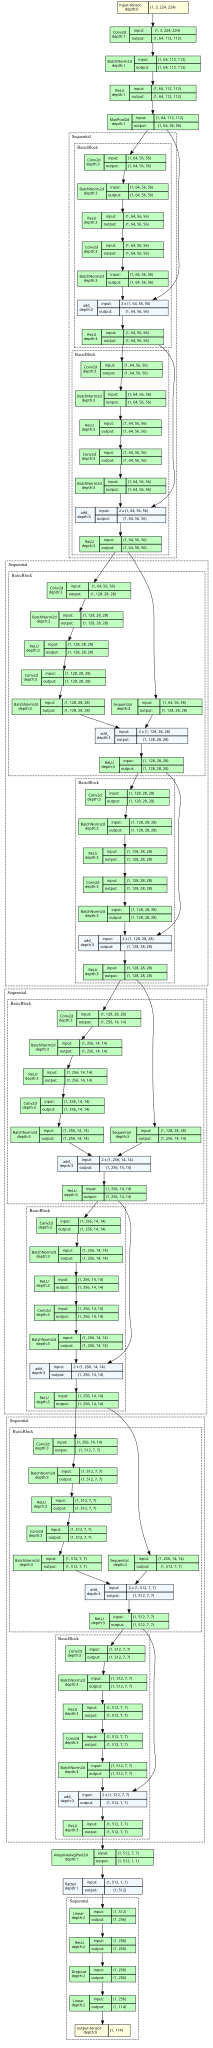

In [ ]:
draw_graph(
    resnet18_baseline,
    input_size=(1, 3, 224, 224),
    expand_nested=True,
    device='cuda'
).visual_graph


🎨 Deep fejjel

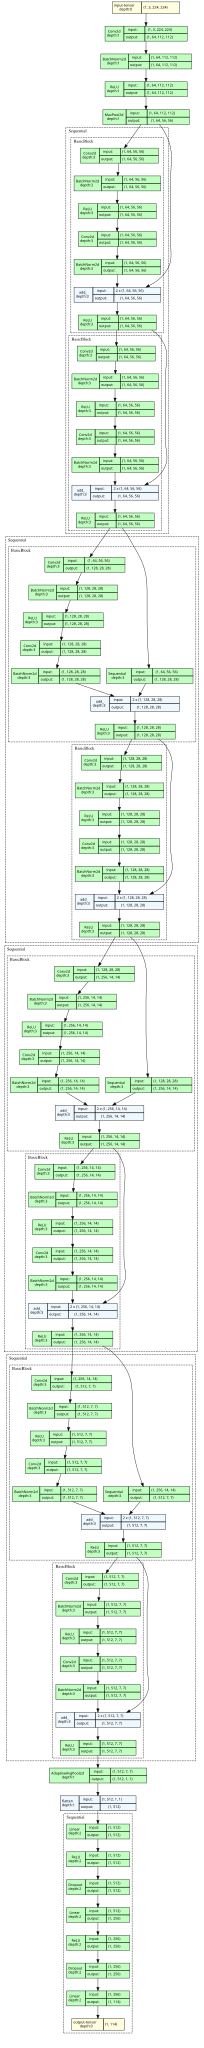

In [ ]:
draw_graph(
    resnet18_deep,
    input_size=(1, 3, 224, 224),
    expand_nested=True,
    device='cuda'
).visual_graph


🎨 Hybrid fejjel – figyelem: Conv2d miatt 4D input kell!

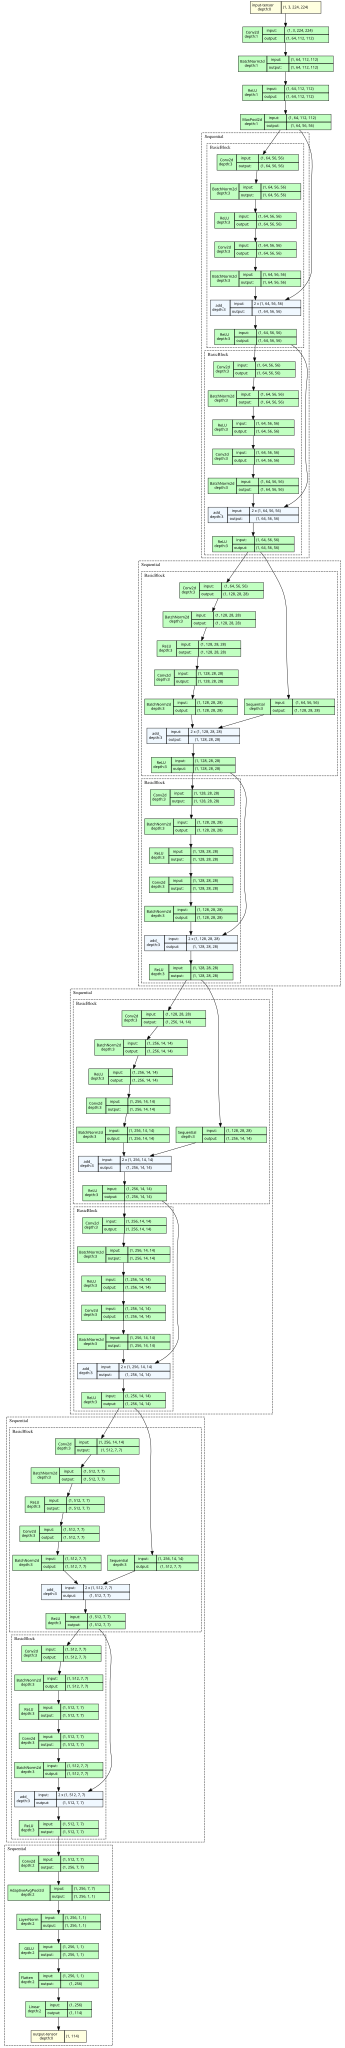

In [ ]:
draw_graph(
    resnet18_hybrid,
    input_size=(1, 3, 224, 224),
    expand_nested=True,
    device="cuda"
).visual_graph

🧾 Kiíró blokk – a teljes hibrid modell szerkezete:

In [ ]:
print("🔧 Teljes ResNet18 Hybrid modell felépítése:\n")
print(resnet18_hybrid)

🔧 Teljes ResNet18 Hybrid modell felépítése:

ResNet18HybridHead(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchN

🧠 Csak a fej (head) kiírása külön:

In [ ]:
print("\n🧠 Hybrid fej (custom classification head):\n")
print(resnet18_hybrid.head)


🧠 Hybrid fej (custom classification head):

Sequential(
  (0): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
  (1): AdaptiveAvgPool2d(output_size=(1, 1))
  (2): LayerNorm((256, 1, 1), eps=1e-05, elementwise_affine=True)
  (3): GELU(approximate='none')
  (4): Flatten(start_dim=1, end_dim=-1)
  (5): Linear(in_features=256, out_features=114, bias=True)
)


🚀 7. Inferencia – 1. fázis: előtanítás nélküli teljesítmény a három modellen

Minden modellre külön blokkban végezzük el az inferenciát a `test_loader` segítségével.

In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import time

# 🔄 Transzformációk (ugyanaz, mint eddig)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# 📁 Teszthalmaz betöltése
test_dir = "/content/imagenet_splitted_db/test"
test_dataset = ImageFolder(test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# ✅ Használt osztályok (fontos a mapping-hez)
class_names = test_dataset.classes
num_classes = len(class_names)

📦 7.1 Inferencia – ResNet18 + baseline fej

In [ ]:
resnet18_baseline.eval()
all_preds, all_labels, all_probs = [], [], []

start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Baseline modell – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet18_baseline(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

inference_time_baseline = time.time() - start_time


🔍 Baseline modell – tesztelés: 100%|██████████| 284/284 [00:18<00:00, 15.38it/s]


📦 7.2 Inferencia – ResNet18 + deep fej

In [ ]:
resnet18_deep.eval()
all_preds_d, all_labels_d, all_probs_d = [], [], []

start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Deep modell – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet18_deep(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds_d.extend(preds.cpu().numpy())
        all_labels_d.extend(labels.cpu().numpy())
        all_probs_d.extend(probs.cpu().numpy())

inference_time_deep = time.time() - start_time


🔍 Deep modell – tesztelés: 100%|██████████| 284/284 [00:15<00:00, 18.29it/s]


📦 7.3 Inferencia – ResNet18 + hybrid fej

In [ ]:
resnet18_hybrid.eval()
all_preds_h, all_labels_h, all_probs_h = [], [], []

start_time = time.time()

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="🔍 Hybrid modell – tesztelés"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet18_hybrid(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds_h.extend(preds.cpu().numpy())
        all_labels_h.extend(labels.cpu().numpy())
        all_probs_h.extend(probs.cpu().numpy())

inference_time_hybrid = time.time() - start_time


🔍 Hybrid modell – tesztelés: 100%|██████████| 284/284 [00:15<00:00, 18.29it/s]


📊 8. Metrikák számítása – mindhárom saját modellre (baseline, deep, hybrid)

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    top_k_accuracy_score, confusion_matrix, classification_report
)

def evaluate_metrics(y_true, y_pred, y_probs, model_name, inference_time):
    top1 = accuracy_score(y_true, y_pred)
    top5 = top_k_accuracy_score(y_true, y_probs, k=5, labels=range(len(class_names)))
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n🔍 Vizsgálat eredményei ({model_name} – tanítás nélkül):")
    print(f"✅ Top-1 Accuracy:  {top1:.4f}")
    print(f"✅ Top-5 Accuracy:  {top5:.4f}")
    print(f"🎯 Precision:       {precision:.4f}")
    print(f"🎯 Recall:          {recall:.4f}")
    print(f"🎯 F1-score:        {f1:.4f}")
    print(f"⏱️ Inference time:  {inference_time:.2f} sec")

    return {
        "top1": top1,
        "top5": top5,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "time": inference_time
    }

📈 Metrikák meghívása a három modellhez

In [ ]:
metrics_baseline = evaluate_metrics(
    np.array(all_labels), np.array(all_preds), np.array(all_probs),
    "ResNet18 + Baseline fej", inference_time_baseline
)

metrics_deep = evaluate_metrics(
    np.array(all_labels_d), np.array(all_preds_d), np.array(all_probs_d),
    "ResNet18 + Deep fej", inference_time_deep
)

metrics_hybrid = evaluate_metrics(
    np.array(all_labels_h), np.array(all_preds_h), np.array(all_probs_h),
    "ResNet18 + Hybrid fej", inference_time_hybrid
)



🔍 Vizsgálat eredményei (ResNet18 + Baseline fej – tanítás nélkül):
✅ Top-1 Accuracy:  0.0052
✅ Top-5 Accuracy:  0.0304
🎯 Precision:       0.0093
🎯 Recall:          0.0072
🎯 F1-score:        0.0011
⏱️ Inference time:  18.48 sec

🔍 Vizsgálat eredményei (ResNet18 + Deep fej – tanítás nélkül):
✅ Top-1 Accuracy:  0.0050
✅ Top-5 Accuracy:  0.0265
🎯 Precision:       0.0003
🎯 Recall:          0.0071
🎯 F1-score:        0.0006
⏱️ Inference time:  15.54 sec

🔍 Vizsgálat eredményei (ResNet18 + Hybrid fej – tanítás nélkül):
✅ Top-1 Accuracy:  0.0047
✅ Top-5 Accuracy:  0.0286
🎯 Precision:       0.0041
🎯 Recall:          0.0076
🎯 F1-score:        0.0014
⏱️ Inference time:  15.54 sec


🧩 9. Confusion Matrix – 3 modell, klasszikus ábrázolással (matplotlib + seaborn)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=True)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

🟦 Baseline modell Confusion Matrix

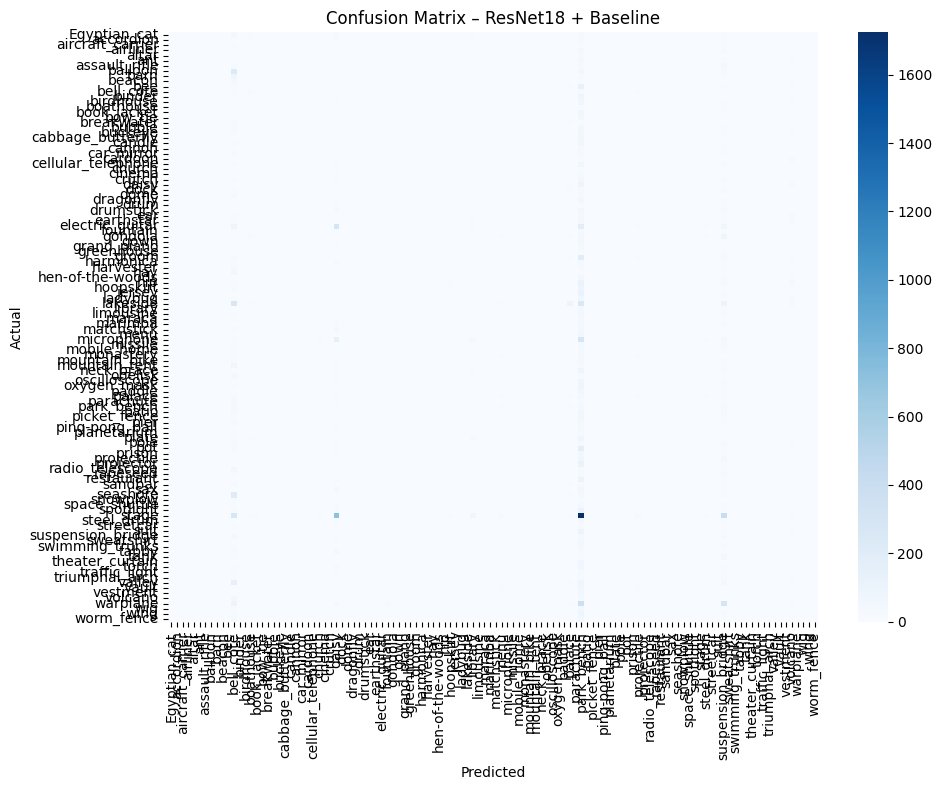

In [ ]:
plot_confusion_matrix(all_labels, all_preds, class_names, "Confusion Matrix – ResNet18 + Baseline")


🟩 Deep modell Confusion Matrix

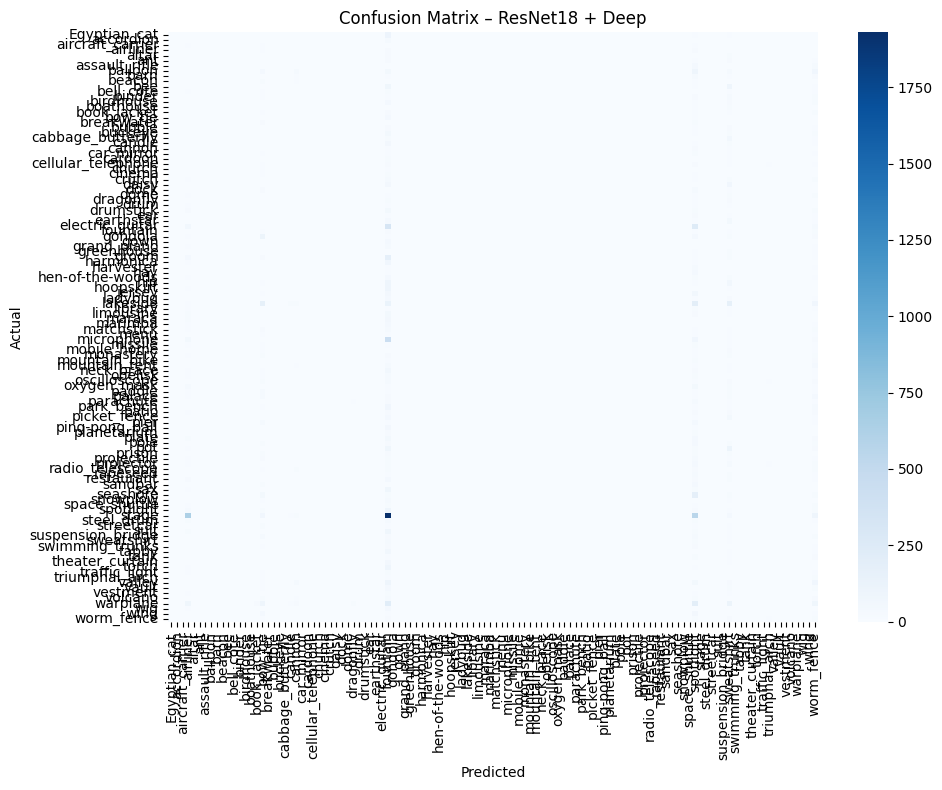

In [ ]:
plot_confusion_matrix(all_labels_d, all_preds_d, class_names, "Confusion Matrix – ResNet18 + Deep")


🟨 Hybrid modell Confusion Matrix

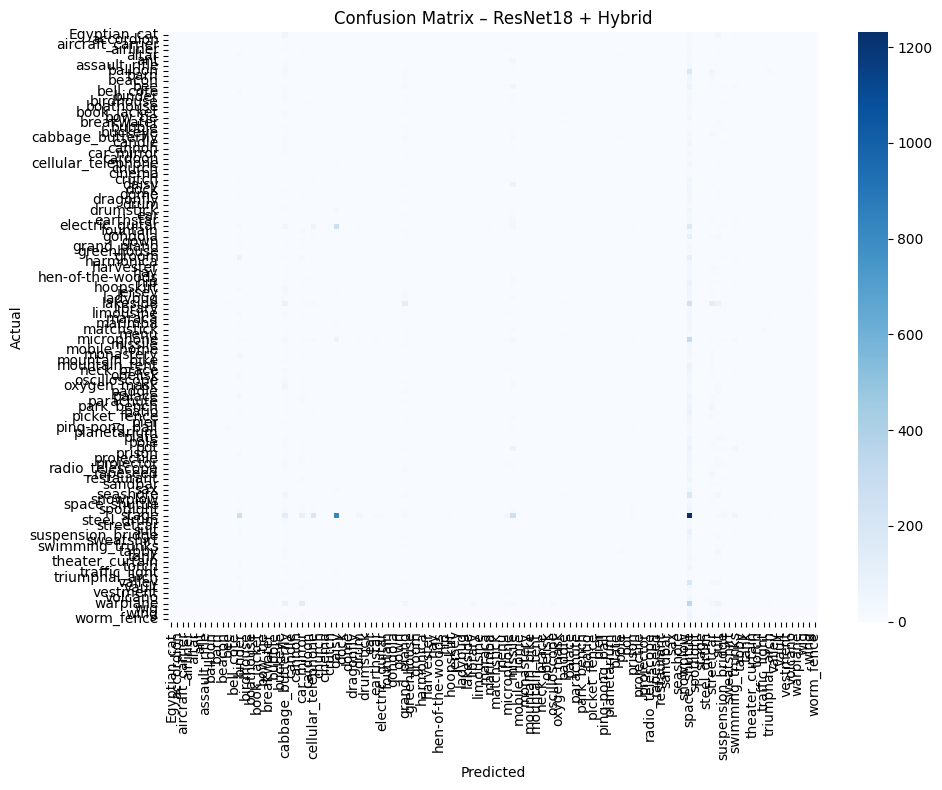

In [ ]:
plot_confusion_matrix(all_labels_h, all_preds_h, class_names, "Confusion Matrix – ResNet18 + Hybrid")


🎨 10. Szebb Confusion Matrix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_pretty(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(18, 16))  # Nagyobb ábra, hogy elférjen minden
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names)

    plt.title(title, fontsize=18)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()


🟦 Baseline modell (szépített)

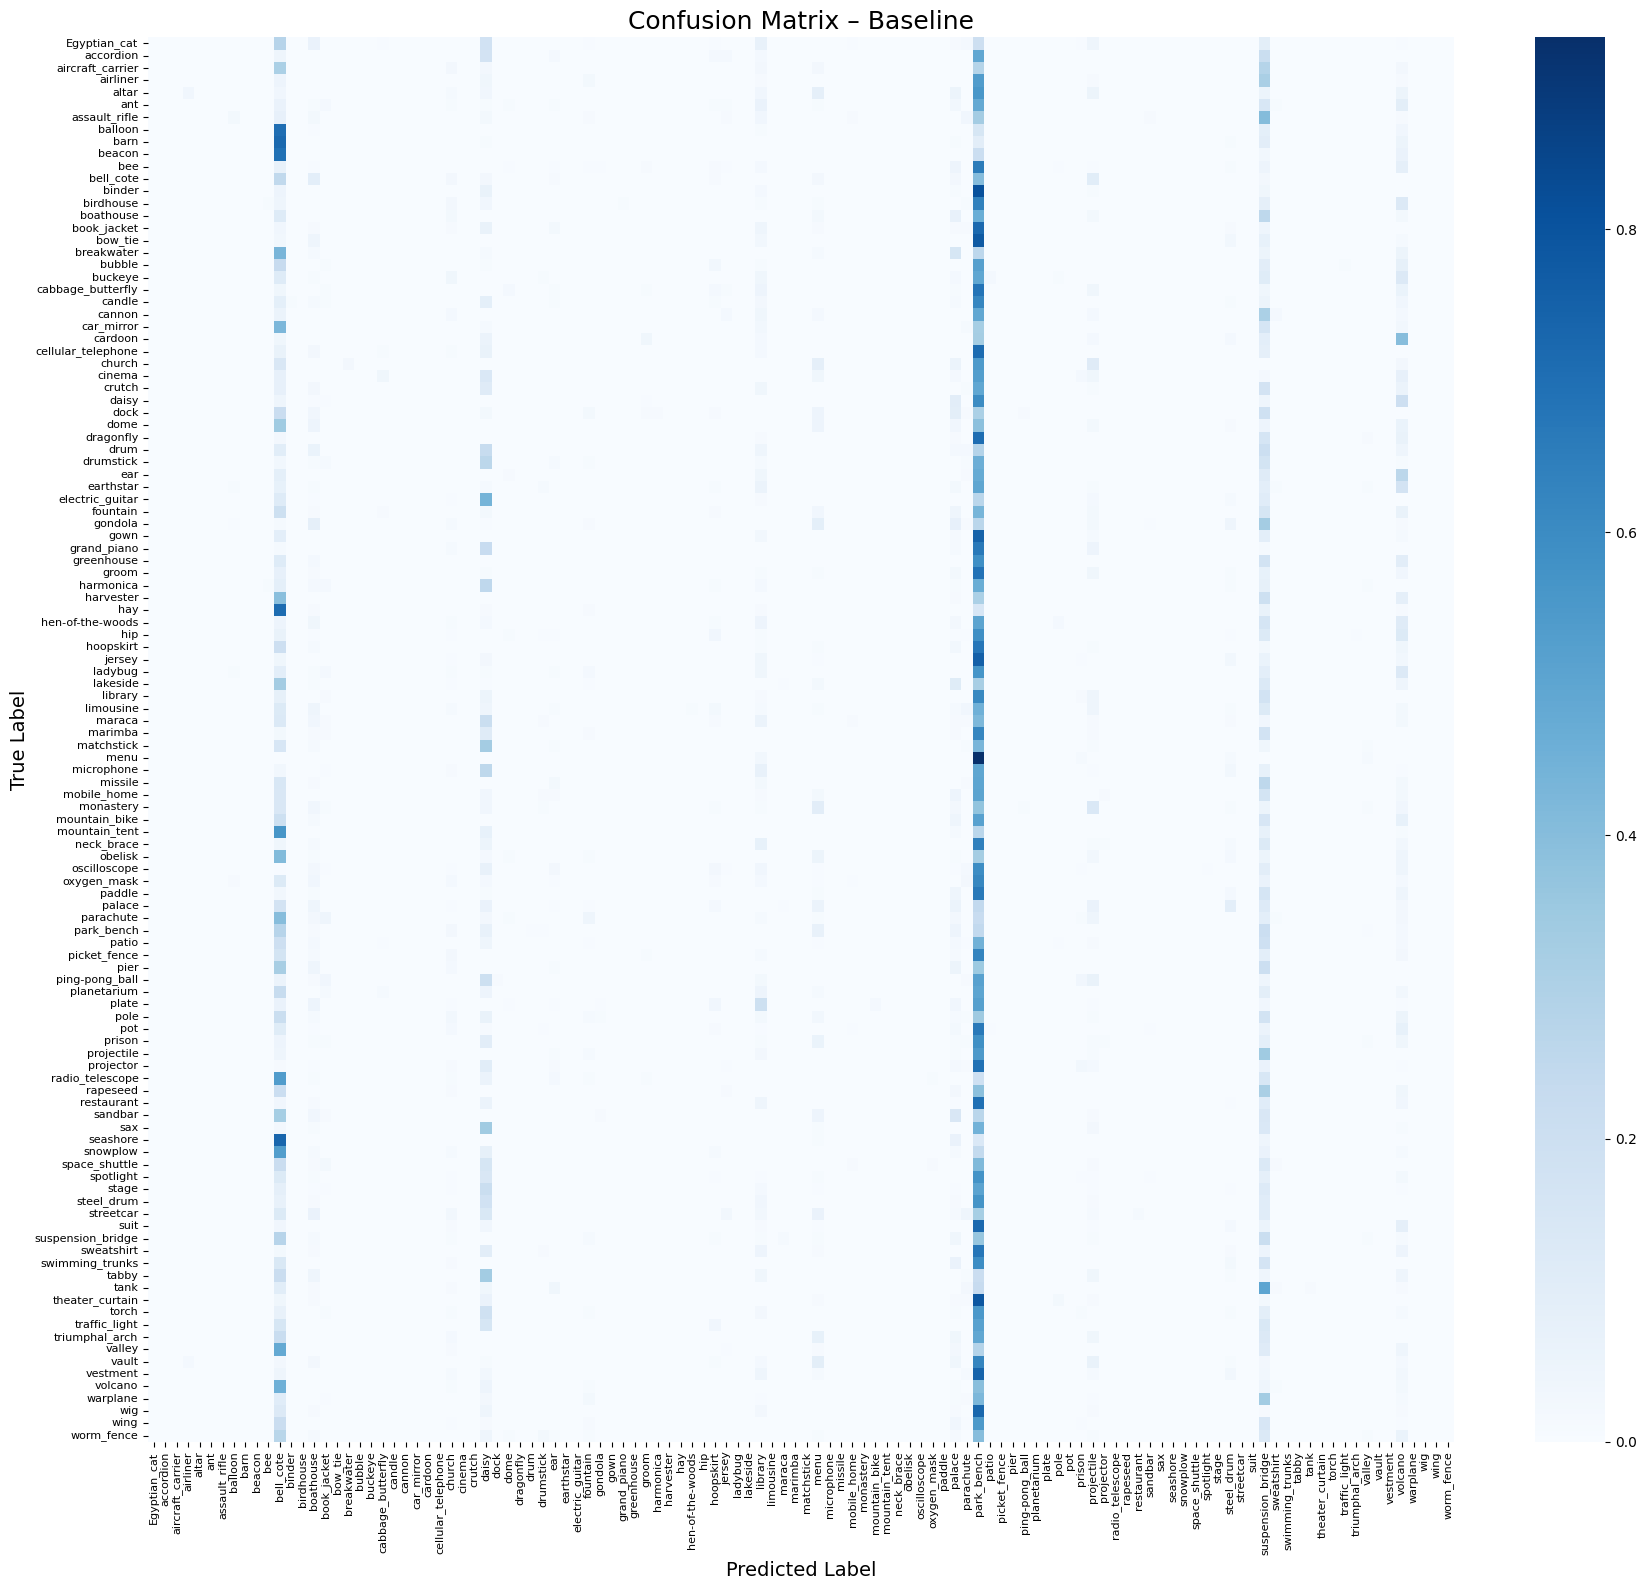

In [ ]:
plot_confusion_matrix_pretty(all_labels, all_preds, class_names, "Confusion Matrix – Baseline")


🟩 Deep modell (szépített)

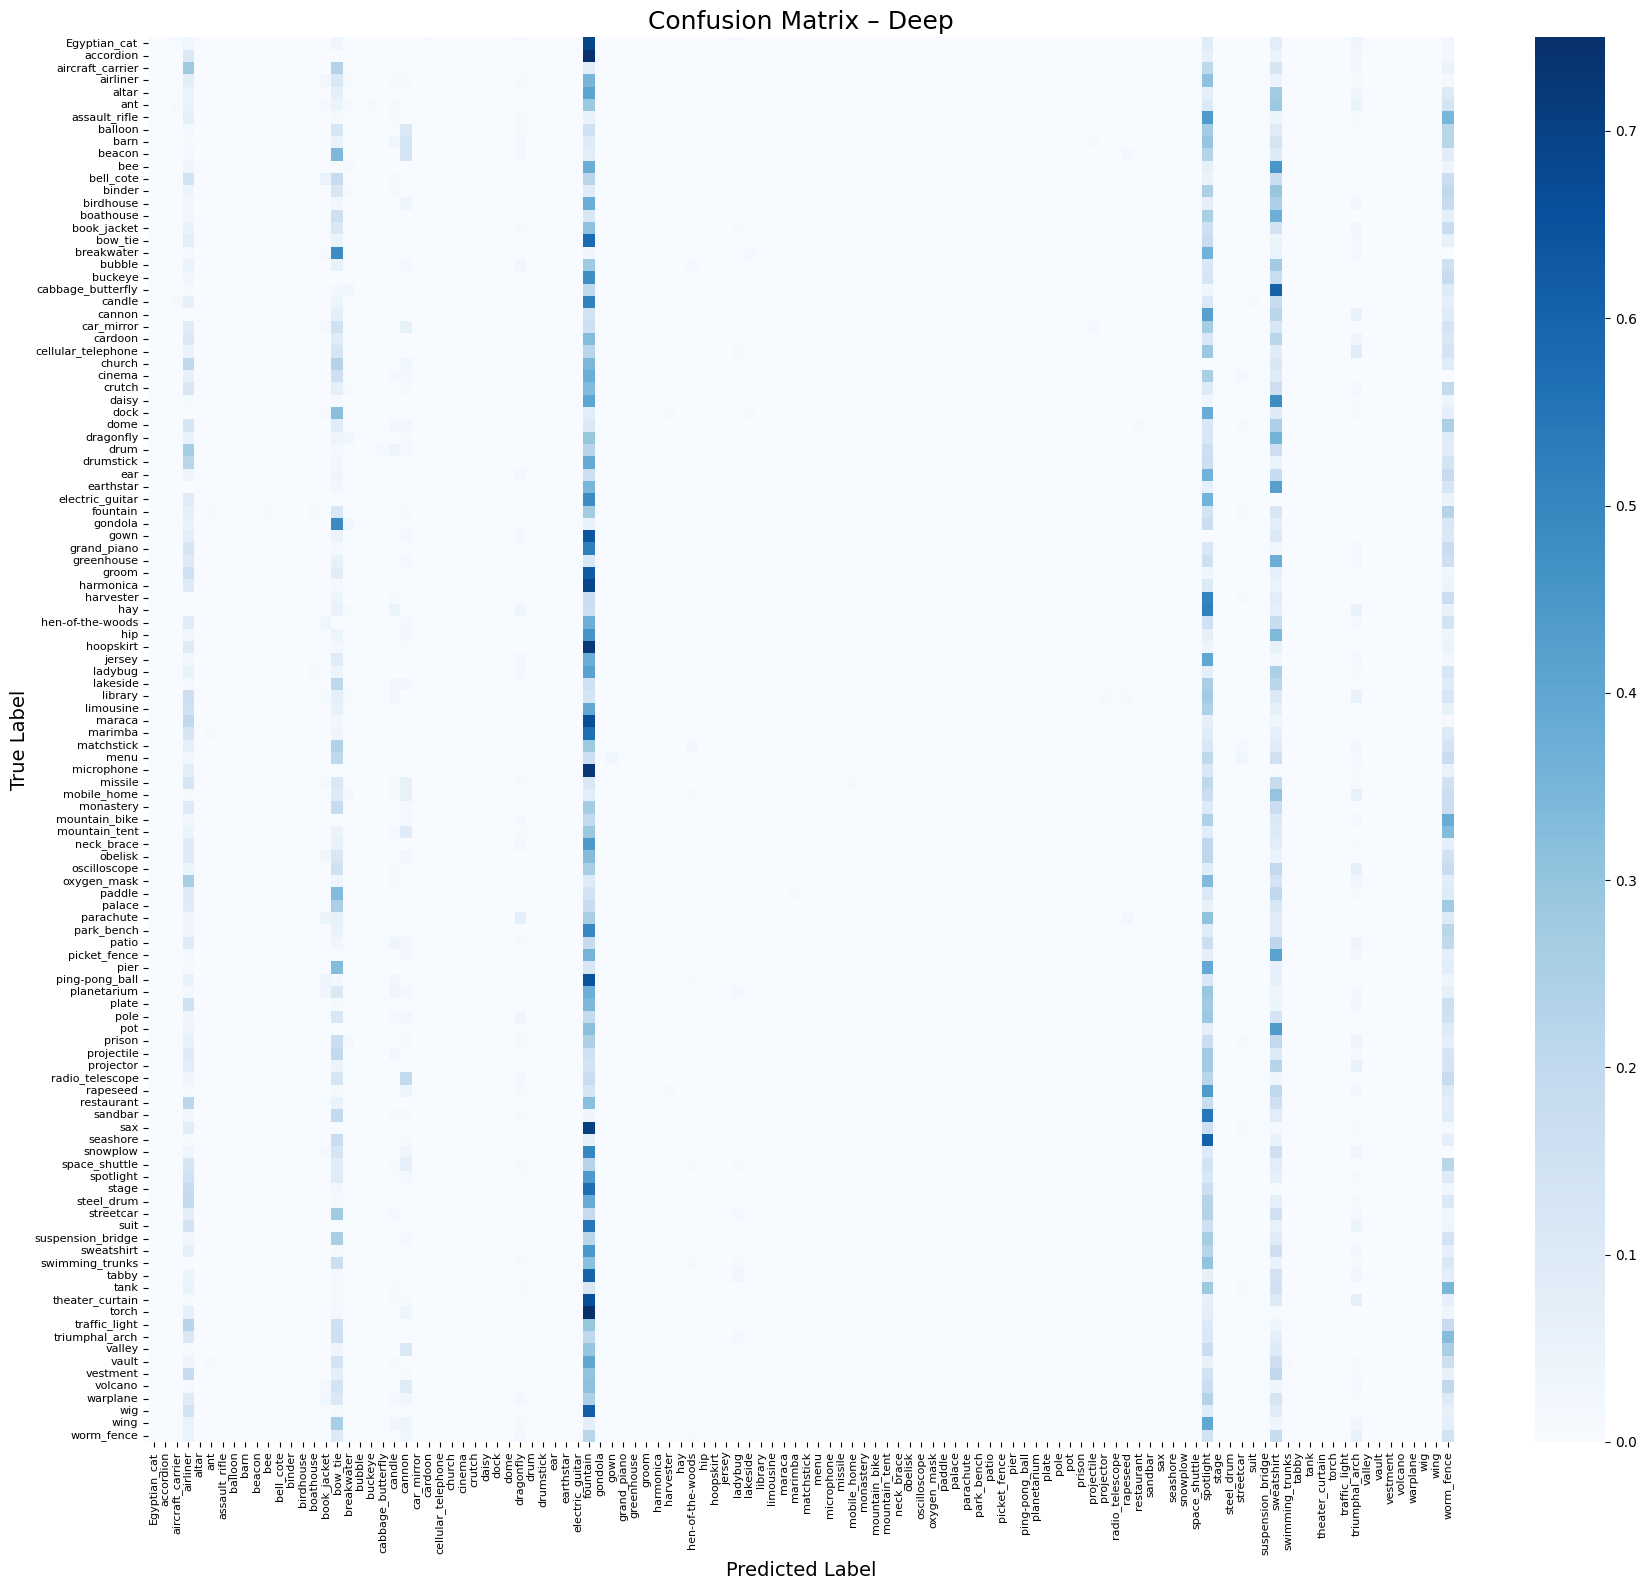

In [ ]:
plot_confusion_matrix_pretty(all_labels_d, all_preds_d, class_names, "Confusion Matrix – Deep")


🟨 Hybrid modell (szépített)

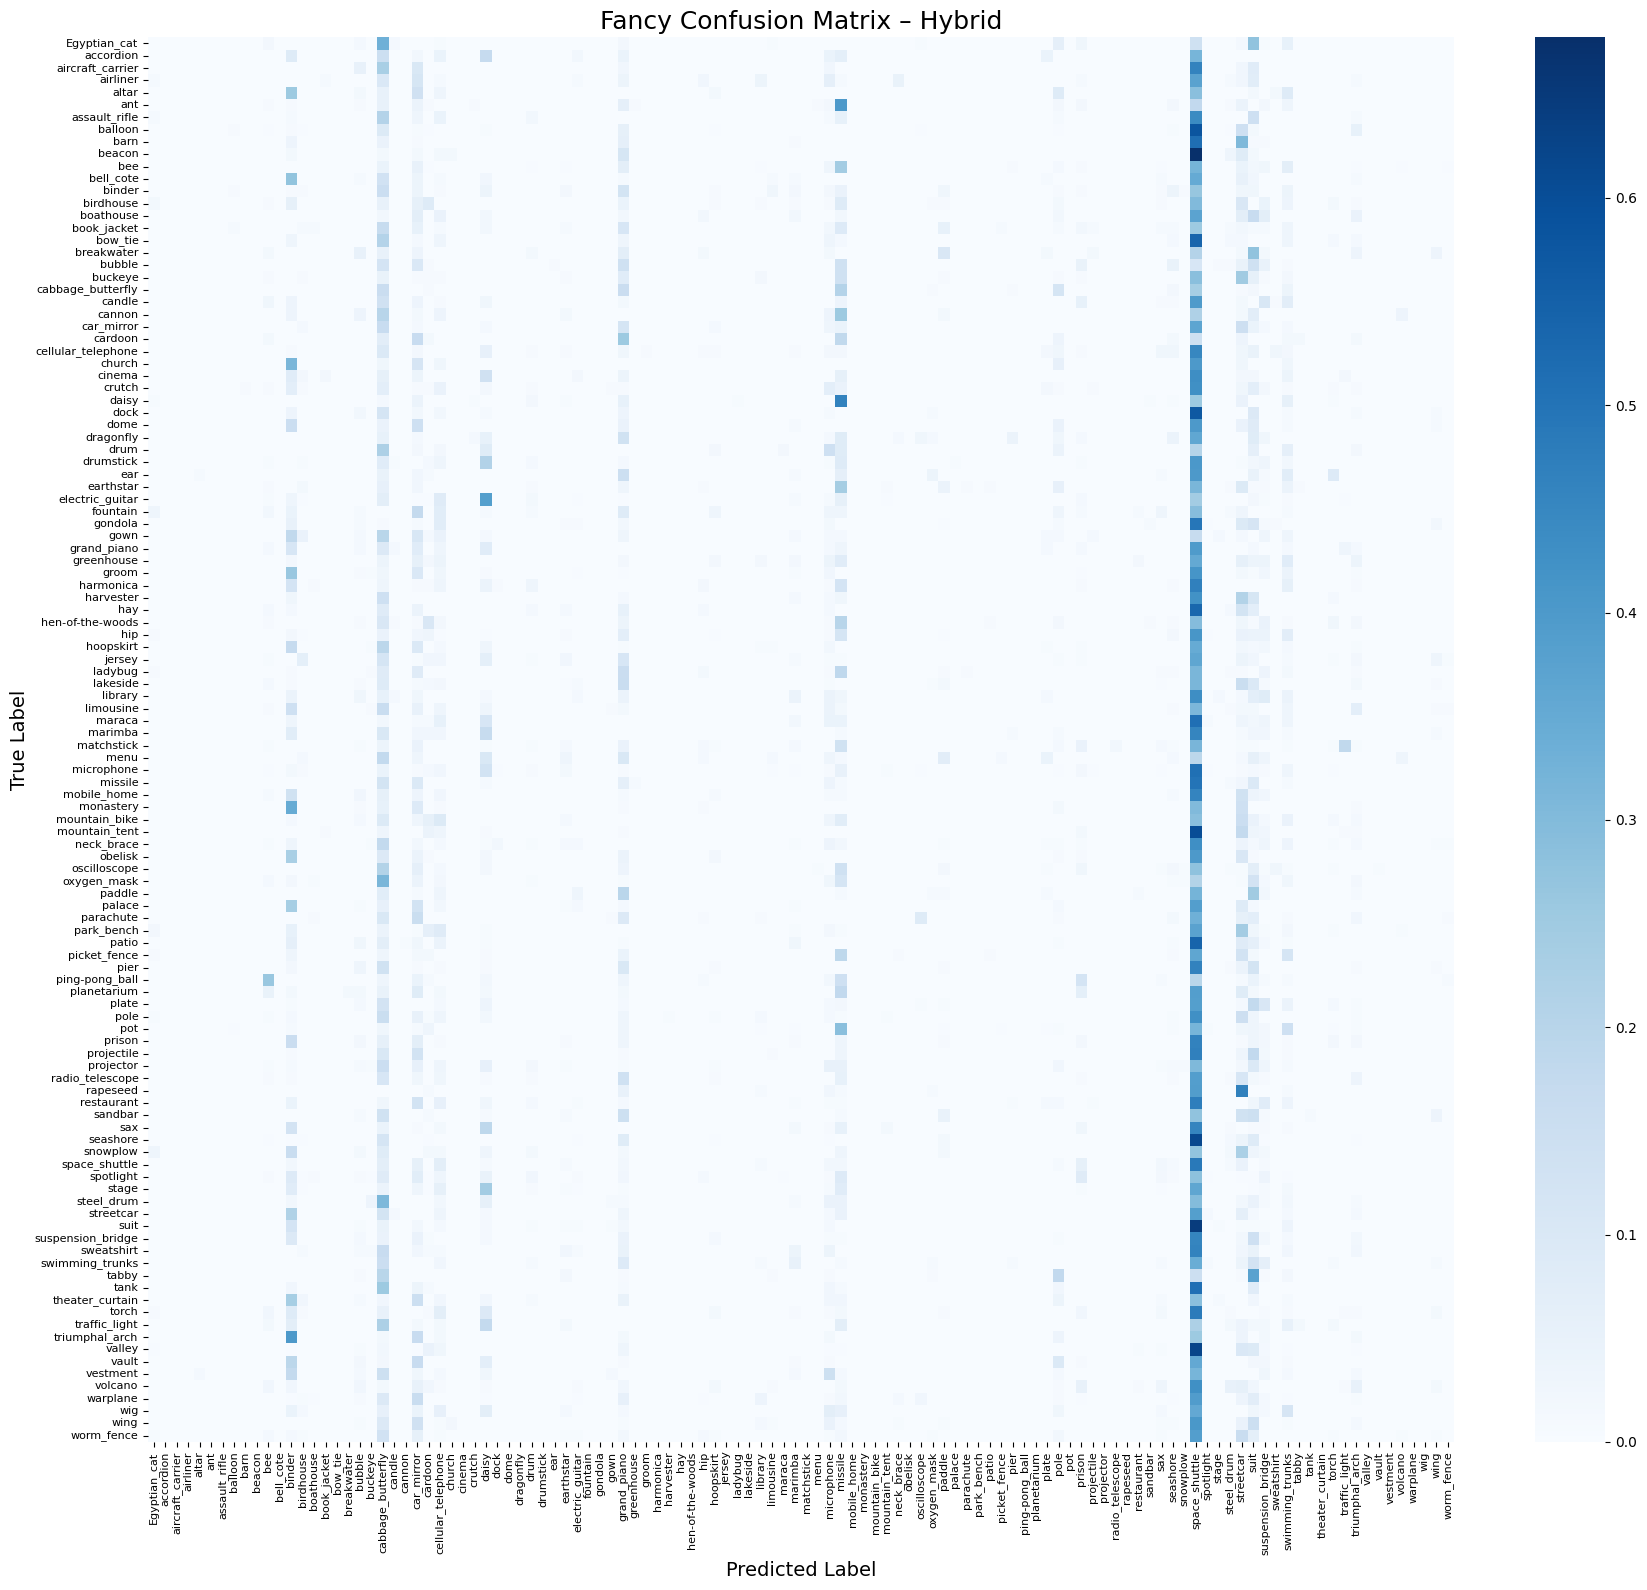

In [ ]:
plot_confusion_matrix_pretty(all_labels_h, all_preds_h, class_names, "Fancy Confusion Matrix – Hybrid")


✅ 11. Részletes osztályonkénti metrikák (Precision / Recall / F1) és CSV export – 3 modellhez

Az alábbi kód mindhárom saját ResNet18 alapú modellre elkészíti:
- osztályonkénti precízió, recall, F1-score értékeket
- képernyőre írja a részletes jelentést
- CSV-fájlba menti jól azonosítható névvel

🛠️ Közös függvény


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

def export_classification_report(y_true, y_pred, class_names, model_name_slug):
    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0
    )
    df = pd.DataFrame(report_dict).transpose()
    csv_filename = f"stage1_class_report_{model_name_slug}.csv"
    df.to_csv(csv_filename, index=True)
    print(f"\n📄 Exportálva: {csv_filename}")
    return df

🟦 Baseline modell

In [ ]:
print("📋 Baseline modell – osztályonkénti metrikák:\n")
df_baseline = export_classification_report(all_labels, all_preds, class_names, "resnet18_baseline")
display(df_baseline.head())


📋 Baseline modell – osztályonkénti metrikák:


📄 Exportálva: stage1_class_report_resnet18_baseline.csv


,precision,recall,f1-score,support
Egyptian_cat,0.0,0.0,0.0,145.0
accordion,0.0,0.0,0.0,47.0
aircraft_carrier,0.0,0.0,0.0,39.0
airliner,0.0,0.0,0.0,80.0
altar,0.0,0.0,0.0,59.0


🟩 Deep modell

In [ ]:
print("📋 Deep modell – osztályonkénti metrikák:\n")
df_deep = export_classification_report(all_labels_d, all_preds_d, class_names, "resnet18_deep")
display(df_deep.head())


📋 Deep modell – osztályonkénti metrikák:


📄 Exportálva: stage1_class_report_resnet18_deep.csv


,precision,recall,f1-score,support
Egyptian_cat,0.000000,0.000,0.000000,145.0
accordion,0.000000,0.000,0.000000,47.0
aircraft_carrier,0.000000,0.000,0.000000,39.0
airliner,0.003576,0.075,0.006826,80.0
altar,0.000000,0.000,0.000000,59.0


🟨 Hybrid modell

In [ ]:
print("📋 Hybrid modell – osztályonkénti metrikák:\n")
df_hybrid = export_classification_report(all_labels_h, all_preds_h, class_names, "resnet18_hybrid")
display(df_hybrid.head())


📋 Hybrid modell – osztályonkénti metrikák:


📄 Exportálva: stage1_class_report_resnet18_hybrid.csv


,precision,recall,f1-score,support
Egyptian_cat,0.0,0.0,0.0,145.0
accordion,0.0,0.0,0.0,47.0
aircraft_carrier,0.0,0.0,0.0,39.0
airliner,0.0,0.0,0.0,80.0
altar,0.0,0.0,0.0,59.0


🔍 12. A 10 leggyengébben teljesítő osztály (F1-score alapján)

A következő blokk mindhárom modell osztályonkénti statisztikájából kiválogatja a **Top 10 leggyengébben teljesítő osztályt** az F1-score érték alapján.  
Ez segít azonosítani azokat a kategóriákat, amelyekre a modellek a legbizonytalanabbak voltak.


In [ ]:
def print_worst_classes(df, model_name, top_n=10):
    df_filtered = df.iloc[:-3]  # support, accuracy, macro avg sorokat elhagyjuk
    worst = df_filtered.sort_values("f1-score").head(top_n)
    print(f"\n📉 {model_name} – Top {top_n} leggyengébb osztály (F1-score alapján):\n")
    display(worst[["precision", "recall", "f1-score"]])

🟦 Baseline modell – leggyengébb osztályok

In [ ]:
print_worst_classes(df_baseline, "ResNet18 + Baseline fej")



📉 ResNet18 + Baseline fej – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
Egyptian_cat,0.0,0.0,0.0
accordion,0.0,0.0,0.0
aircraft_carrier,0.0,0.0,0.0
airliner,0.0,0.0,0.0
altar,0.0,0.0,0.0
ant,0.0,0.0,0.0
assault_rifle,0.0,0.0,0.0
balloon,0.0,0.0,0.0
barn,0.0,0.0,0.0
beacon,0.0,0.0,0.0


🟩 Deep modell – leggyengébb osztályok

In [ ]:
print_worst_classes(df_deep, "ResNet18 + Deep fej")



📉 ResNet18 + Deep fej – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
Egyptian_cat,0.0,0.0,0.0
accordion,0.0,0.0,0.0
aircraft_carrier,0.0,0.0,0.0
altar,0.0,0.0,0.0
assault_rifle,0.0,0.0,0.0
ant,0.0,0.0,0.0
balloon,0.0,0.0,0.0
barn,0.0,0.0,0.0
binder,0.0,0.0,0.0
beacon,0.0,0.0,0.0


🟨 Hybrid modell – leggyengébb osztályok

In [ ]:
print_worst_classes(df_hybrid, "ResNet18 + Hybrid fej")


📉 ResNet18 + Hybrid fej – Top 10 leggyengébb osztály (F1-score alapján):



,precision,recall,f1-score
Egyptian_cat,0.0,0.0,0.0
accordion,0.0,0.0,0.0
aircraft_carrier,0.0,0.0,0.0
airliner,0.0,0.0,0.0
altar,0.0,0.0,0.0
ant,0.0,0.0,0.0
assault_rifle,0.0,0.0,0.0
barn,0.0,0.0,0.0
birdhouse,0.0,0.0,0.0
beacon,0.0,0.0,0.0


✅ x. GPU memóriahasználat, batch sebesség statisztika

In [ ]:
# --- GPU memóriahasználat ---
gpu_mem_allocated = torch.cuda.memory_allocated() / (1024 ** 3)
gpu_mem_reserved = torch.cuda.memory_reserved() / (1024 ** 3)

print(f"💾 GPU memória (lefoglalt): {gpu_mem_reserved:.2f} GB")
print(f"💾 GPU memória (használt):  {gpu_mem_allocated:.2f} GB")

💾 GPU memória (lefoglalt): 0.97 GB
💾 GPU memória (használt):  0.17 GB
